## Title: Data Visualization Notebook - Eigendecomposition Analysis

### Author: Nilay Kumar
Multicellular Systems Engineering Lab

### Update Author: Stephen Cini
Dowling Lab

Department of Chemical and Biomolecular Engineering

University of Notre Dame

#### Summary
This notebook is used for visualizing the data generated by `master_hessian_analysis.py`. The data plotted here corresponds to Figure 3E of the manuscript.

In [ ]:
# Adding dependencies folder to the path. Dependencies stores all teh classes used in bayesian optimization BO
import sys
sys.path.append("/Users/scini/Documents/GitHub/ReverseEngineeringMorphogenesis/emulatorGPBO_update_StephenCini2026")
# Loading in libraries
import pandas as pd
import matplotlib.pyplot as plt
import spatial_efd
import math 
import signac
import numpy as np
import os.path
import os
import torch
import gpytorch
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import similaritymeasures
#from smt.sampling_methods import LHS
# Importing helper libraries for bayesian optimization
from dependencies.data_preprocessing_class import DataPreprocessing
from dependencies.gaussian_process_regression_class import GaussianProcessRegression
from dependencies.acquisition_functions_class import AcqisitionFunctions
from dependencies.geometry_writer import GeometryWriter
from dependencies.feature_extractor_4 import FeatureExtractor

#### Preparing Data for Analysis in a Jupyter Notebook

In this section, we outline the data preparation process for our analysis, including the perturbation of key parameters and the structure of Frechet error arrays utilized in the calculation of non-diagonal elements of the Hessian matrix.

#### 1A. Parameter Perturbation

We perturbed seven important parameters that define the edge length (*Lo<sup>col</sup><sub>A</sub>*, *Lo<sup>col</sup><sub>B</sub>*, *Lo<sup>col</sup><sub>L</sub>*) and contractility (*k<sup>col</sup><sub>A</sub>*, *k<sup>col</sup><sub>B</sub>*, *k<sup>col</sup><sub>L</sub>*) of columnar cells, along with the extracellular matrix (ECM) strength (*K<sub>ECM</sub>*). These parameters were perturbed both individually and pairwise by 70% to explore their impact on the system.

#### 1B. Frechet Error Array Structure for Hessian Matrix Calculation

To compute the non-diagonal elements of the Hessian matrix, we established a structured approach (master_hessian_analysis.py) for evaluating apical and basal Frechet errors across various parameter combinations. The following outlines the methodology:

- The main loop iterates over all the parameters, denoted as Parameter 1 (*$P_{1}$*), where each parameter is considered in sequence.
- Within this loop, an embedded 'for' loop is initiated just ahead of *$P_{1}$*, which iterates over the same set of parameters, denoted as Parameter 2 (*$P_{2}$*).
- For each parameter combination (*$P_{1}$*, *$P_{2}$*), we evaluate apical and basal Frechet errors using the following sequence of parameter adjustments:
    1. *$P_{1}$* + 0.7*$P_{1}$*, *$P_{2}$* + 0.7*$P_{2}$*
    2. *$P_{1}$* - 0.7*$P_{1}$*, *$P_{2}$* - 0.7*$P_{2}$*
    3. *$P_{1}$* + 0.7*$P_{1}$*, *$P_{2}$* - 0.7*$P_{2}$*
    4. *$P_{1}$* - 0.7*$P_{1}$*, *$P_{2}$* + 0.7*$P_{2}$*

#### 1C. Perturbation of Parameter Values

For each parameter, we considered variations that were 70% above and 70% below the equilibrium values that define the shape of the disc. This allowed us to comprehensively explore the effects of parameter changes on the system's behavior.


In [8]:
# Loading frechet error for parameter bounds for approximating hessian of non diagonal element
error_target_sampled_apical = np.load('output_data_files/error_target_sampled_apical.npy')
error_target_sampled_basal = np.load('output_data_files/error_target_sampled_basal.npy')

# Loading frechet error for parameter bounds for approximating hessian of diagonal element
error_apical_one_d = np.load('output_data_files/error_apical_one_d.npy')
error_basal_one_d = np.load('output_data_files/error_basal_one_d.npy')

# Flatten the one d arrays
error_apical_one_d = error_apical_one_d.flatten()
error_basal_one_d = error_basal_one_d.flatten()

#### 2.  Calculating hessian matrix of frechet errors using finite differences

Following formulaes were used for calculation of Frechet errors. Diagonal and non diagonal elements were evaluated separately

1. Calcaulation of non-diagonal elements 
    - $H_{ij} = \frac{F_{\theta_{i} + \Delta\theta_{i}, \theta_{j} + \Delta\theta_{j}} - F_{\theta_{i} - \Delta\theta_{i}, \theta_{j} + \Delta\theta_{j}} - F_{\theta_{i} + \Delta\theta_{i}, \theta_{j} - \Delta\theta_{j}} + F_{\theta_{i} - \Delta\theta_{i}, \theta_{j} - \Delta\theta_{j}}}{4\Delta\theta_{i}\Delta\theta_{j}} $, where H is the Hessian, F denotes the Frechet error and $\theta$ denotes the parameter value.


2. Hessian matrix is symmetric
    - $H_{ji} = H_{ij}$


3. Calculation of non diagonal elements
    - $H_{ii} = \frac{F_{\theta_{i} + \Delta\theta_{i}} - 2F_{\theta_{i}} + F_{\theta_{i} - \Delta\theta_{i}}}{\Delta\theta_{i}^{2}} $
    - $F_{\theta_{i}} = 0$
    

5. Two different methods are used for calculating hessians.
    - calc_method == 1: Relative change in parameter values are calculated as exact change in parameter values (0.7$P_{i}$).
    - calc_method == 2: Relative change in parameter values are calculated as percentage change in parameters (0.7)

In [9]:
# Defining calculation methodologu of hessian (1: exact, 2: Percentage change)
calc_method = 2
# Totalnuber of model parameters varied
num_param = 7
# Labels of the parameters varied
params_lhs = ('$k^{col}_{A}$','$k^{col}_{B}$','$k^{col}_{L}$','$Lo^{col}_{A}$','$Lo^{col}_{B}$','$Lo^{col}_{L}$','$K_{ECM}$')
# Value of parameters for the equilibrium case
param_val = [0.01, 0.00003981, 0.01, 0.2, 0.1, 3, 0.002511886]

# Initializing hessian matrices for the apical and basal frechet errors
hessian_f_a = np.zeros((num_param,num_param))
hessian_f_b = np.zeros((num_param,num_param))

""" Part 1: Calculating non-diagonal elements"""
# Initializing the counter
k = 0
# Looping over all the parameter values
for i in range(num_param-1):
    # Interating from the parameter index ahead of the parameter index listed in previous loop to end
    for j in range(i+1,num_param):
        # Calculating the denominator of hessian tern based on calculationmethodology
        if calc_method == 1:
            di_dj = (0.7*param_val[i])*(0.7*param_val[j])
        elif calc_method == 2:
            di_dj = 0.7*0.7        
        # Calculation of hessain for apical surface
        # The 1st and 2nd term of frechet errors arrays impoted are cases where both parameter value srae increased or decreased
        # The 3rd and 4th term of frechet errors arrays impoted are cases where one parameter increases and other decreases
        hessian_f_a[i,j] = (error_target_sampled_apical[4*k] + error_target_sampled_apical[4*k+1] - error_target_sampled_apical[4*k+2] - error_target_sampled_apical[4*k+3])/(4*di_dj)
        # Hessian is symmetric
        hessian_f_a[j,i] = hessian_f_a[i,j]
        # Similar methodologu of calculation of hessian for basal surface
        hessian_f_b[i,j] = (error_target_sampled_basal[4*k] + error_target_sampled_basal[4*k+1] - error_target_sampled_basal[4*k+2] - error_target_sampled_basal[4*k+3])/(4*di_dj)
        hessian_f_b[j,i] = hessian_f_b[i,j]
        # Increasing the iteration counter
        k = k + 1

""" Part 2: Calculating diagonal elements"""
# Iterating over the parameter values
for i in range(num_param):
    # Calculating the denominator of hessian tern based on calculation methodology
    if calc_method == 1:
        di_2 = (0.7*param_val[i])*(0.7*param_val[i])
    elif calc_method == 2:
        di_2 = 0.7**2
    elif calc_method == 3:
        if log_scaling_switch[i] == 0:
            di_2 = (0.7*param_val[i])*(0.7*param_val[i])
        elif log_scaling_switch[i] == 1:
            di_2 = (np.log(1.7))*(np.log(1.7))
    elif calc_method == 4:
        if log_scaling_switch[i] == 0:
            di_2 = (0.7*param_val[i])*(0.7*param_val[i])
        elif log_scaling_switch[i] == 1:
            di_2 = (np.log(0.7*param_val[i]))*(np.log(0.7*param_val[j]))
    # Calculating hessian (diagonal elements) for apical and basal surfaces
    hessian_f_a[i,i] = (error_apical_one_d[2*i] + error_apical_one_d[2*i+1])/di_2
    hessian_f_b[i,i] = (error_basal_one_d[2*i] + error_basal_one_d[2*i+1])/di_2

#### 3. Visualizing the Hessian Matrix

Text(0.5, 1.0, '$d^{2}F_{B}/d\\Theta_{i}d\\Theta_{j}$')

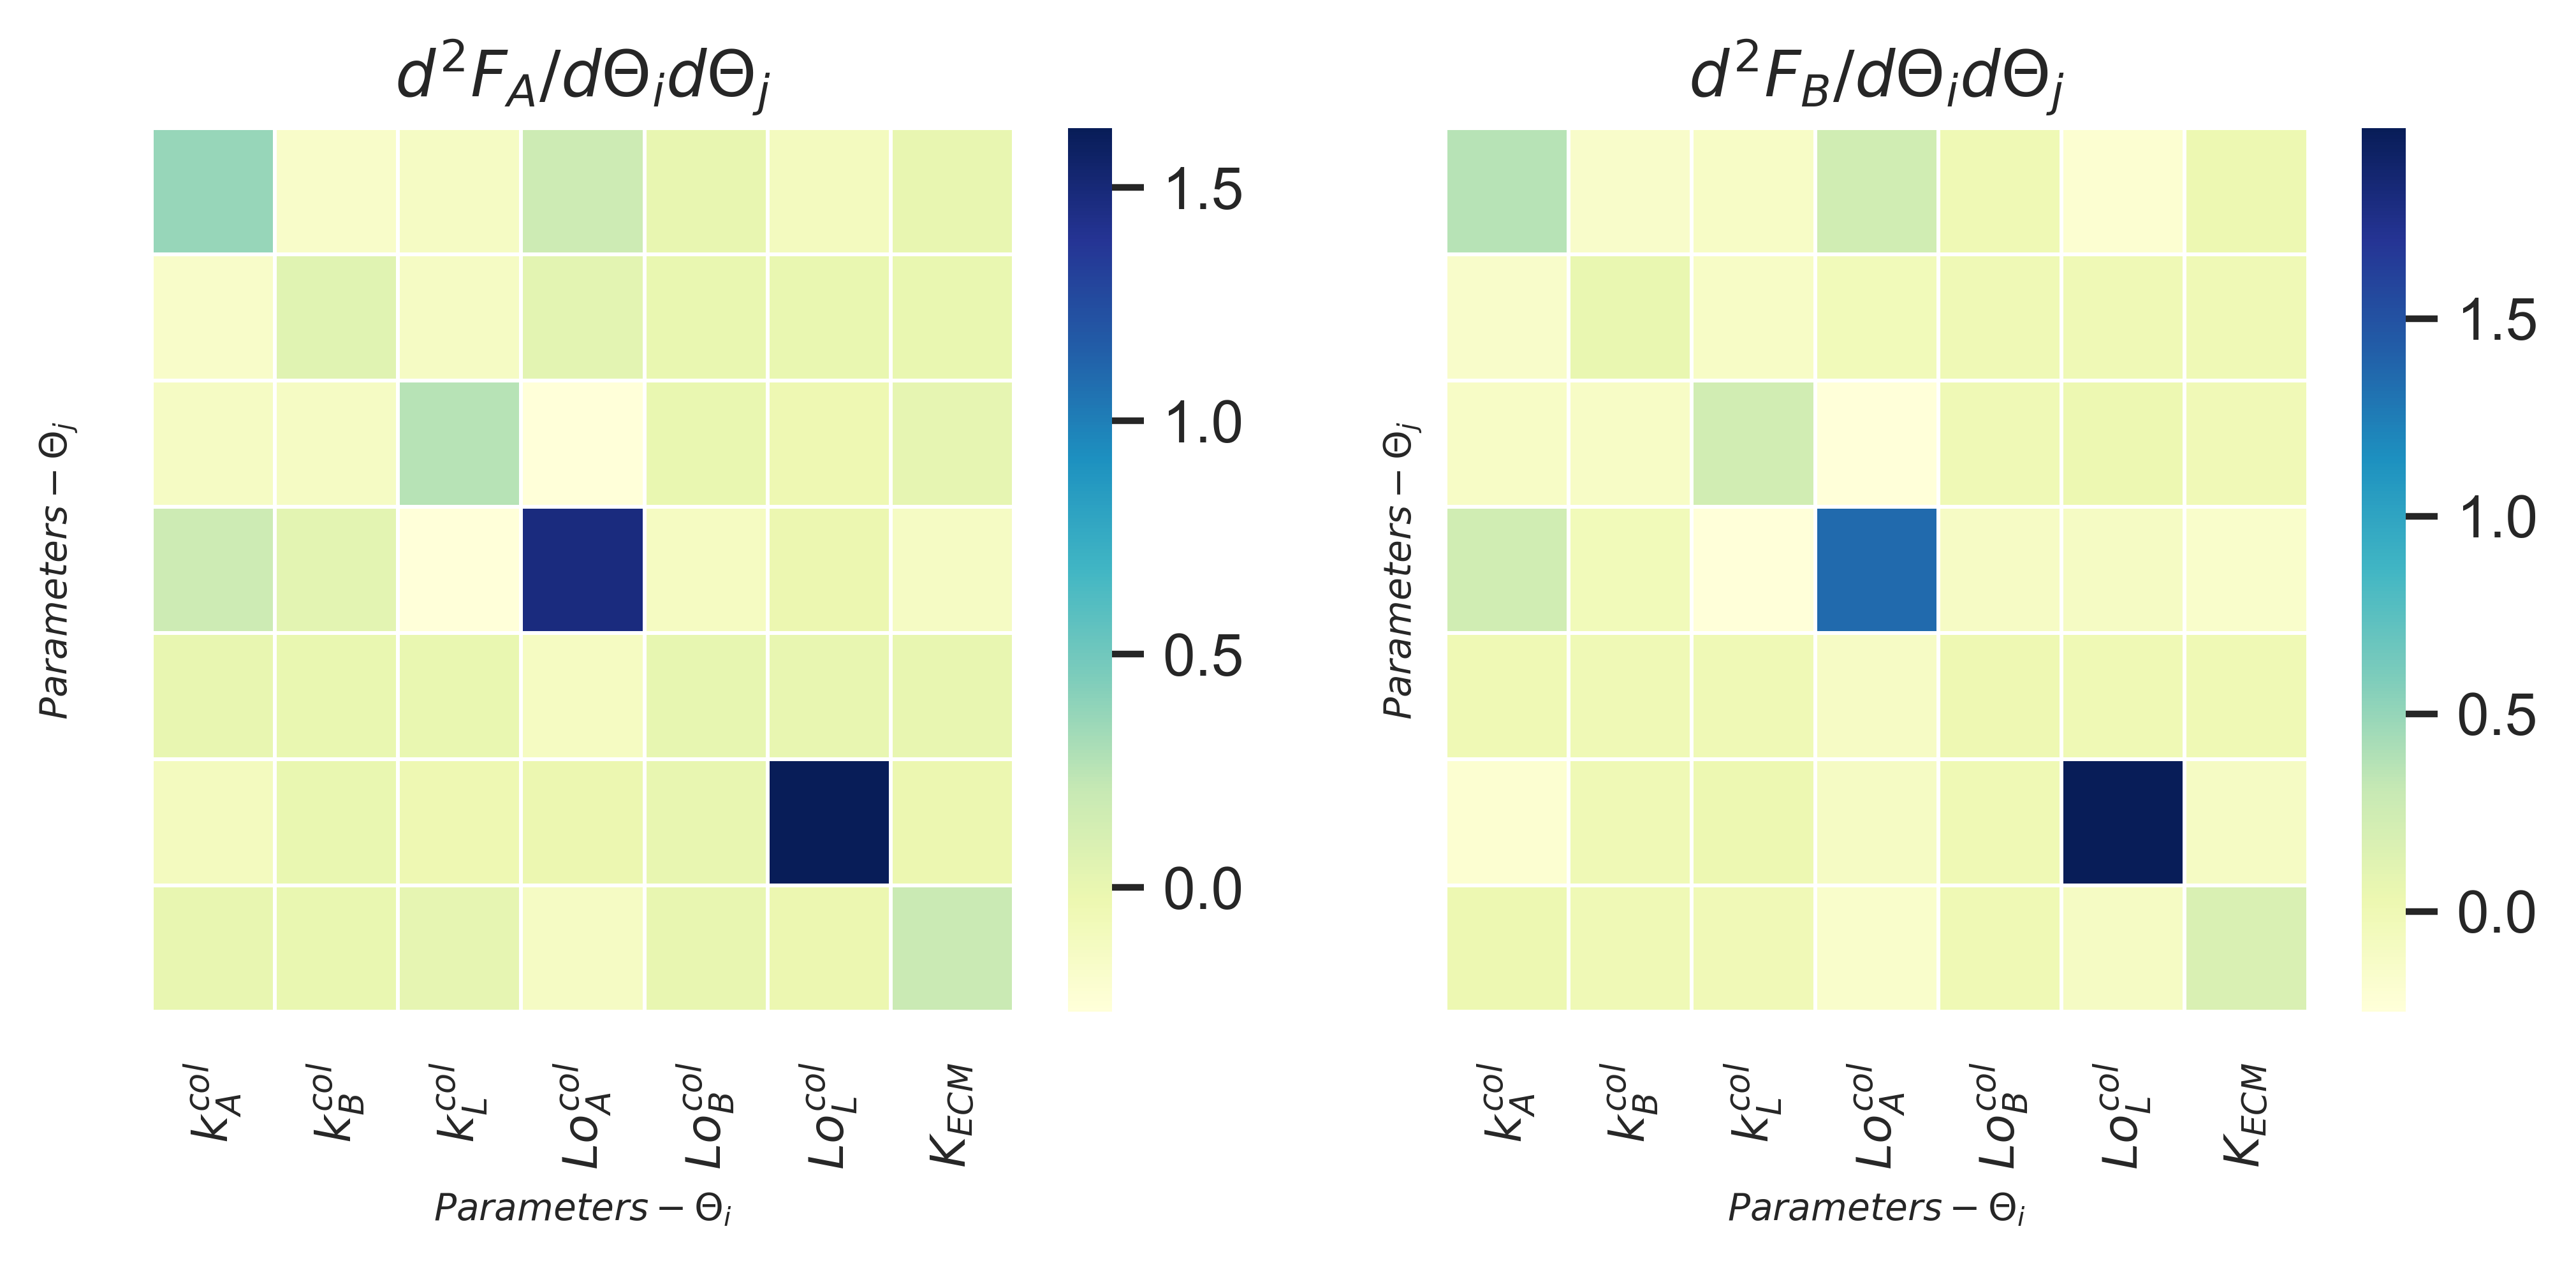

In [10]:
# Creating a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(8,3), sharey=True, dpi=600)
# Subplot 1: Using seaborn to create heatmap of hessian for frechet error calaculated on apical surface
hmap1 = sns.heatmap((hessian_f_a), xticklabels = params_lhs, yticklabels = params_lhs, linewidths=.5, cmap="YlGnBu", ax=axes[0])
# Setting fontsize of x tick labels
axes[0].set_xticklabels(axes[0].get_xmajorticklabels(), fontsize = 9)
# Setting fontsize of y tick labels
axes[0].set_yticklabels(axes[0].get_ymajorticklabels(), fontsize = 9)
# Setting y axis label
axes[0].set_ylabel(r'$Parameters - \Theta_j$', fontsize=7)
# Setting x axis label
axes[0].set_xlabel(r'$Parameters - \Theta_i$', fontsize=7)
# subplot title
axes[0].set_title(r'$d^{2}F_{A}/d\Theta_{i}d\Theta_{j}$')

# Subplot 2: Using seaborn to create heatmap of hessian for frechet error calaculated on basal surface
hmap2 = sns.heatmap((hessian_f_b), xticklabels = params_lhs, yticklabels = params_lhs, linewidths=.5, cmap="YlGnBu", ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xmajorticklabels(), fontsize = 9)
axes[1].set_yticklabels(axes[1].get_ymajorticklabels(), fontsize = 9)
axes[1].set_ylabel(r'$Parameters - \Theta_j$', fontsize=7)
axes[1].set_xlabel(r'$Parameters - \Theta_i$', fontsize=7)
axes[1].set_title(r'$d^{2}F_{B}/d\Theta_{i}d\Theta_{j}$')

#### 3. Computing eigenvalues and eigenvectors for hessian

- Eigenvalue and Eigenvector of the hessian corresponding to frechet error of apical and basal surfaces are calculated
- Eigenvectors corresponding to the four dominant eigenvalues are analyszed

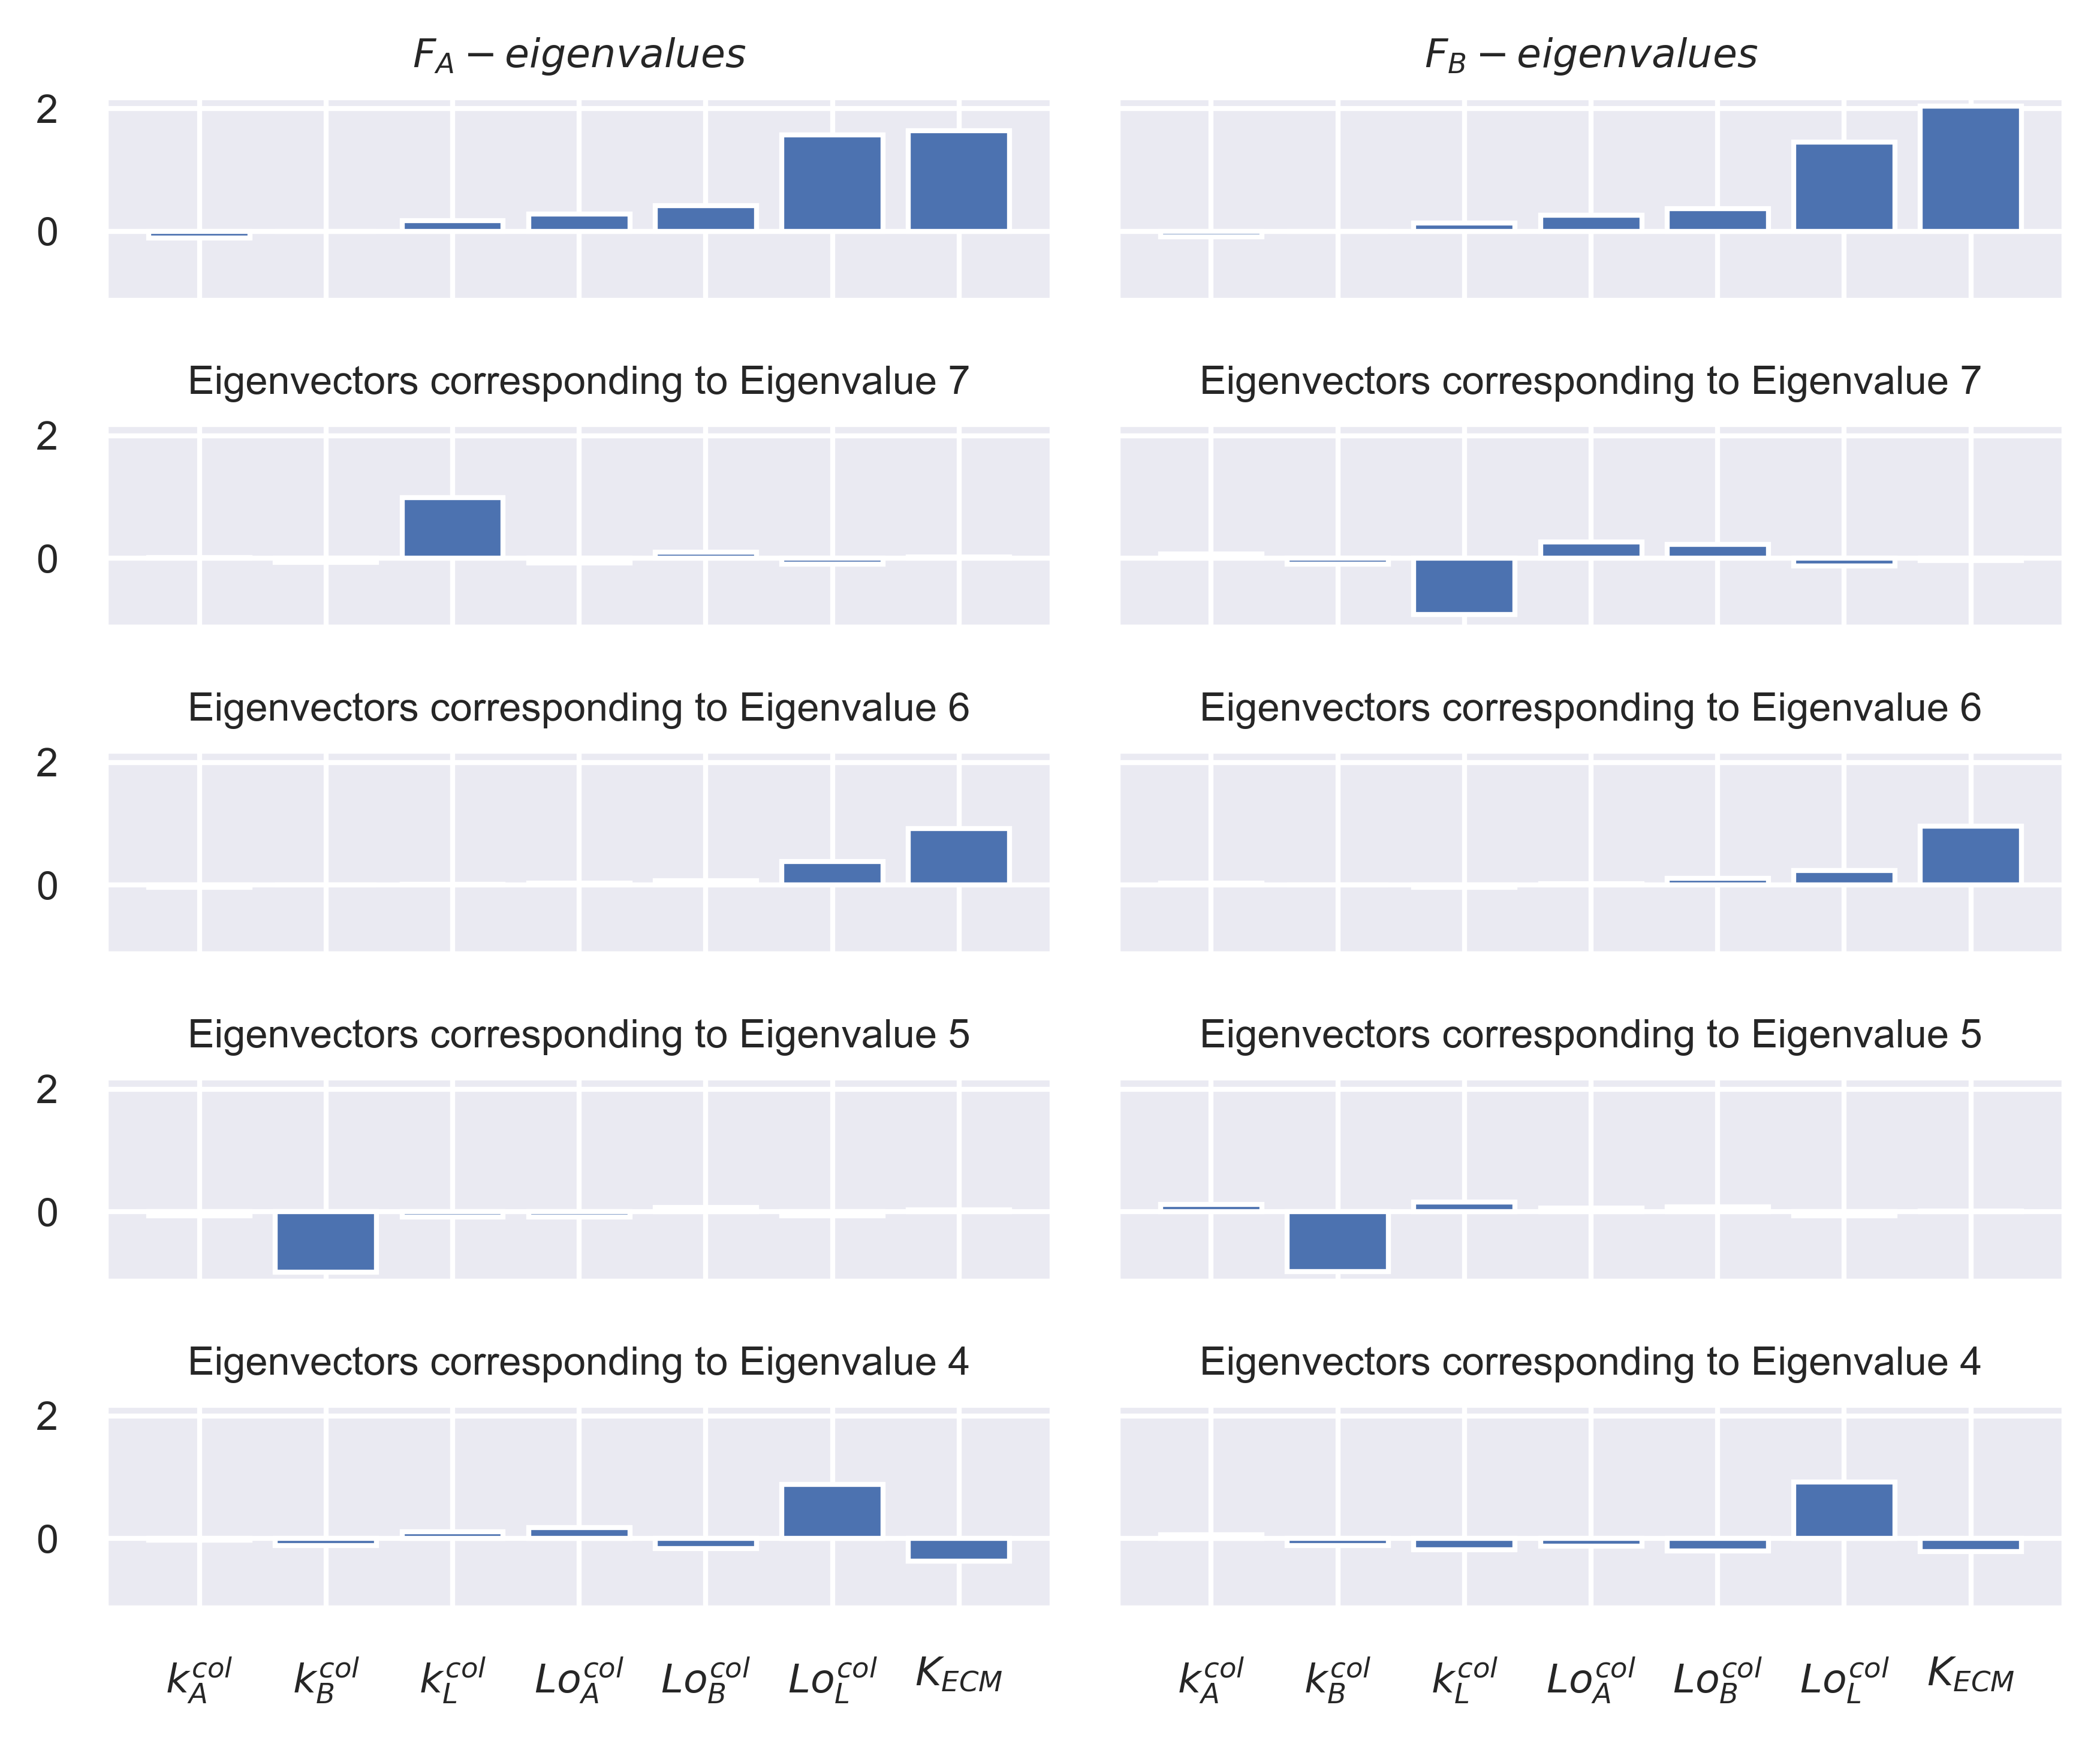

In [11]:
# Calculating eigenvalue and eigenvector of hessian matrix correspondig to frechet error of apical surface 
# np.linalg.eigh is used as the matrix is symmetric
hess_eval_fa, hess_evec_fa = np.linalg.eigh(hessian_f_a)
# Calculating eigenvalue and eigenvector of hessian matrix correspondig to frechet error of basal surface 
hess_eval_fb, hess_evec_fb = np.linalg.eigh(hessian_f_b)

""" Plotting eigenvalues and eigenvectors"""
# Defining figure size and subplot details
fig, ax = plt.subplots(nrows=5, ncols=2, sharex=True, sharey=True, figsize=(6, 5), dpi=600)
# Defining labels of sorted eigenvalues
eig_labels = ('$eig_{1}$', '$eig_{2}$', '$eig_{3}$', '$eig_{4}$', '$eig_{5}$', '$eig_{6}$', '$eig_{7}$')
# Creating position on x axis for placing the bars
y_pos = np.arange(len(eig_labels))

""" Step I: Plotting the eigenvalues as barplot"""
# Plotting eigenvalues corresponding to hessian of frechet apical error
plt.subplot(5, 2, 1)
# Plotting eigenvales as bars
plt.bar(y_pos,hess_eval_fa)
# Defining fontsize
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
# Defining labels of x axis
plt.xticks(y_pos, eig_labels)
# Defining title of plot
plt.title('$F_{A} - eigenvalues$', fontsize=8)
# Plotting eigenvalues corresponding to hessian of frechet basal error
plt.subplot(5, 2, 2)
plt.bar(y_pos,hess_eval_fb)
plt.xticks(fontsize=8)
plt.yticks(fontsize=6)
plt.xticks(y_pos, eig_labels)
plt.title('$F_{B} - eigenvalues$', fontsize=8)

""" Step 2: Plotting the eigenvectors corresponding to the largest eigenvalues"""
# Counter for subplot
k = 3
# Accessing eigenvectors corresponding to two greatest eigenvalues
for i in range(4):
    # Plotting eigenvector corresponding to  i+1th largest eigenvalue of apical frechet error
    plt.subplot(5, 2, k)
    plt.bar(y_pos,hess_evec_fa[6-i,:])
    # Defining fontsize
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    # Defining labels of x axis
    plt.xticks(y_pos, params_lhs)
    # Defining title of plot
    plt.title('Eigenvectors corresponding to Eigenvalue ' + str(7-i), fontsize=8)
    # Increasing counter of the subplot
    k = k + 1
    # Plotting eigenvector corresponding to  i+1th largest eigenvalue of basal frechet error
    plt.subplot(5, 2, k)
    plt.bar(y_pos,hess_evec_fb[6-i,:])
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.xticks(y_pos, params_lhs)
    plt.title('Eigenvectors corresponding to Eigenvalue ' + str(7-i), fontsize=8)
    k = k + 1

# Adjusting spacing between subplots
fig.tight_layout()      

#### 4. Visualization of the eigenvectors corresponding to the dominant eigenvalues of hessian matrix for *$F_{B}$*

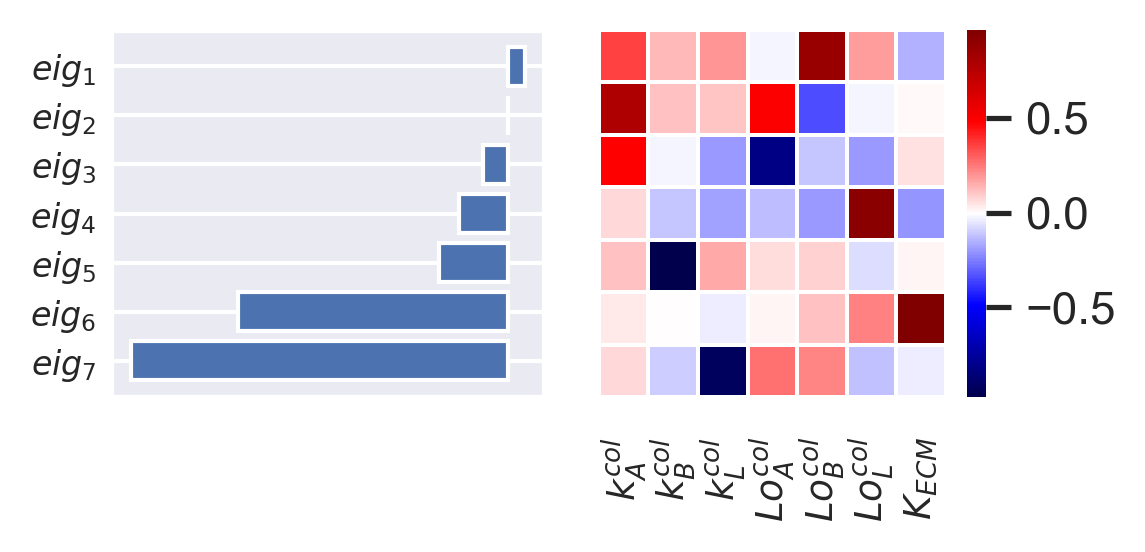

In [12]:
sns.set(rc={"figure.dpi": 300, 'savefig.dpi': 300})
sns.set(rc={'figure.figsize': (4, 2)})

# Plotting the eigenvalues (sorted) of the hessian matrix for the Frechet distance, basal surface
ax1 = plt.subplot(1, 2, 1)
ax1.barh(y_pos, hess_eval_fb)
ax1.set_yticks(y_pos)  # Set the positions of x ticks
ax1.set_yticklabels(eig_labels, fontsize=8, rotation=0)  # Rotate tick labels by 90 degrees
ax1.set_xticks([])  # Remove y ticks
ax1.yaxis.tick_left()  # Position y ticks on the left
ax1.tick_params(axis='both', which='both', length=0)
ax1.invert_yaxis()
ax1.invert_xaxis()


# Create the heatmap on the existing subplot (ax2)
ax2 = plt.subplot(1, 2, 2)  # Modify this to match the position of your second subplot
sns.heatmap((hess_evec_fb), xticklabels=params_lhs, yticklabels=[], linewidths=0.5, cmap="seismic")
# Set labels and other attributes for the heatmap plot (ax2)
ax2.set_xticklabels(ax2.get_xmajorticklabels(), fontsize=9)
ax2.set_yticklabels(ax2.get_ymajorticklabels(), fontsize=9)
# Display the master plot with all subplots
plt.tight_layout()
plt.show()